## Day5
- FA01K1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras


## Attention Q K V 
- attention 이란 ? QK'V ->  상관도[QK']를 결과로 
- cross -> self -> multi ( vector 가 길어지는 것에서 안정적인 모델이 되었다. )
- page 465
- 계층이 깊어 지며 왜곡 - 잔차 연결 = 최초신호가 무엇인지 힌트를 주는것 

## 사전 훈련 언어모델
- LM 미리 학습된 데이터로 다음 단어 예측,
    규모가 커진다면 LLM이라고 불려 진다. 

In [3]:
# inference day 4
import transformers # huggin face transformers lib
from transformers import AutoTokenizer, AutoModelForCausalLM 
# AutoModelForCausalLM 모델 아키텍처가 다양함 

#model_path = '/workspace/kogpt2'
model_id = 'gemma-4-E2B-it'

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id) # 언어 모델 학습이 완료된 가중치 조회 



Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

In [5]:
print(model)


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)


In [7]:
x = torch.arange(10)

print(x)
print(x.numel())

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
10


In [6]:
print(f'model parameter: {sum(p.numel() for p in model.parameters()):,}')

model parameter: 125,164,032


In [ ]:
# inference day 4 update 
import transformers # huggin face transformers lib
from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM  # 신규 api 대응 이슈로 인해 PreTrainedTokenizerFast 사용 
# AutoModelForCausalLM 모델 아키텍처가 다양함 

model_path = '/workspace/kogpt2'

tokenizer = PreTrainedTokenizerFast.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path) # 언어 모델 학습이 완료된 가중치 조회 

print(model)


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: /workspace/kogpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)


In [9]:
prompt = '나는 너를 사랑하는데, 너도 나를'
input_token = tokenizer.encode(prompt, return_tensors='pt')

# 존재하는 token인지 확인 
pd.DataFrame({
    'token': tokenizer.tokenize(prompt),
    'int_sequence': input_token.flatten().tolist()
}).T

# 직접 분석을 위해 model에 시퀀스를 춘다. 
with torch.inference_mode():
    output_sentence = model(input_token)

print(type(output_sentence))
print(output_sentence.keys())
print(output_sentence.logits.shape) # 배치크기, 시퀀스 길이 어휘 루 


<class 'transformers.modeling_outputs.CausalLMOutputWithCrossAttentions'>
odict_keys(['logits', 'past_key_values'])
torch.Size([1, 7, 51200])


## page 463 sequence to sequence 

In [ ]:

# 기본 언어 모델 LM
token_list = tokenizer.tokenize(prompt)
logits = output_sentence.logits[0]  # (시퀀스 길이, 어휘 수)

# 각 입력 토큰 위치마다 최대값 계산 (벡터화)
expect_prob = torch.softmax(logits, dim=-1)
next_token_probablity, next_token_id = expect_prob.max(dim=-1)  # (시퀀스 길이,)

expect_token_list = tokenizer.convert_ids_to_tokens(next_token_id.tolist())

rows = pd.DataFrame({
    '입력 토큰': token_list,
    '예측 토큰': expect_token_list,
    '확률': next_token_probablity.tolist(),
})
rows['확률'] = rows['확률'].round(3)
display(rows.set_index('입력 토큰').T)

입력 토큰,▁나는,▁너,를,▁사랑,"하는데,",▁너도,▁나를
예측 토큰,"▁""",를,▁사랑,해,▁너,▁나를,▁사랑
확률,0.01,0.158,0.044,0.209,0.167,0.113,0.772



## LLM 이란
- "*Base" 라고 있는 모델이 기본, 여기에 fineTune 수행된것이 제거 된것(커스터마이징) 

In [ ]:
from pathlib import Path
import transformers # huggin face transformers lib
from transformers import AutoTokenizer, AutoModelForCausalLM  # 신규 api 대응 이슈로 인해 PreTrainedTokenizerFast 사용 

#model_path = 'qwen3-1.7b-base' # 일반 언어 모델
model_path = 'qwen3-1.7b' # 훈련된 지시 수행 모델 post trained  instruction following

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(model_path)



Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

In [23]:
import torch 

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

model.to(device)

#prompt = '배 타고 배 먹으니 배 아프다. 영어로 번역'
# list 형식으로 batch 추론방식 
#prompt = [
#    'I love you. 한국어로 번역:',
#    """ <- 단순 지시만 하면 코드 이어서 작성함, 해설이라고 명시적으로 작서
#    device = 'cpu' 
#    if torch.cuda.is_available():
#        device = 'cuda'
#    model.to(device)
#    """
#]

prompt = [
    'I love you. 한국어로 번역:',
    """
    아래 코드에 대한해설 

    device = 'cpu' 
    if torch.cuda.is_available():
        device = 'cuda'
    model.to(device)
    """
]

#input_token = tokenizer.encode(prompt, return_tensors='pt')
input_sequence = tokenizer(prompt, return_tensors='pt', padding=True, padding_side='left')
# 직접 분석을 위해 model에 시퀀스를 춘다. 

# cuda 사용을 위한 정리 
for key in input_sequence:
    input_sequence[key] = input_sequence[key].to(device)

with torch.inference_mode():
    output_sequence = model.generate(
        **input_sequence,
        max_new_tokens=128,
    )


for i in range(len(prompt)):
    output_sentence = tokenizer.decode(output_sequence[i], skip_special_tokens=True)
    print(f'prompt : {i}, {prompt[i]}')
    print('--'*20, f'output {i}','--'*20)
    print(output_sentence)
    print()

print(output_sentence) # 배치크기, 시퀀스 길이 어휘 루 


prompt : 0, I love you. 한국어로 번역:
---------------------------------------- output 0 ----------------------------------------
I love you. 한국어로 번역: "I love you" is a common phrase used to express deep affection and romantic feelings. It is often used in personal relationships, such as between a couple, a parent and child, or between friends. The phrase is also used in more formal contexts, such as in love letters or in romantic movies. However, the exact meaning can vary depending on the context and the relationship between the people involved. In some cases, it may be used to express a sense of gratitude or admiration, while in other cases, it may be used to express a sense of love and affection. The phrase is widely recognized and used around the world, and it

prompt : 1, 
    아래 코드에 대한해설 

    device = 'cpu' 
    if torch.cuda.is_available():
        device = 'cuda'
    model.to(device)
    
---------------------------------------- output 1 ----------------------------------------

  

- 사후 훈련 Post training
    - huggingface 의 chat template 

In [28]:
prompt = 'i love you. 한국어로 번역:'
message = [
    {
        "role":"user","content": prompt        
    },
    {
        "role":"system", "content": "너는 도널드 트럼프 클론이야."
    }
]

text = tokenizer.apply_chat_template(message, tokenize=False, add_generation_prompt=True)
print(text)

<|im_start|>user
i love you. 한국어로 번역:<|im_end|>
<|im_start|>system
너는 도널드 트럼프 클론이야.<|im_end|>
<|im_start|>assistant



In [ ]:
prompt = """
Astronomers are studying a star with a 1.5 solar radius and 1.1 solar masses. When the star's surface is not covered by dark spots, its Teff is 6000K. However, when 40% of its surface is covered by spots, the overall photospheric effective temperature decreases to 5500 K. In the stellar photosphere, when examining the ratio of the number of neutral atoms of Ti in two energetic levels (level 1 and level 2), astronomers have observed that this ratio decreases when the star has spots. What is the factor by which this ratio changes when the star does not have spots compared to when it has spots? Note that the transition between the energy levels under consideration corresponds to a wavelength of approximately 1448 Å. Assume that the stellar photosphere is in LTE.

A. ~2.9
B. ~1.1
C. ~4.5
D. ~7.8
"""
## 정답은 C 
messages = [
    {'role': 'system', 'content': '너는 도널드 트럼프 스타일로 설명하는 코딩 도우미야. 생각과 응답을 모두 한국어로 작성할 것.'},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True, enable_thinking=True)
print(text)

<bos><|turn>system
<|think|>
너는 도널드 트럼프 스타일로 설명하는 코딩 도우미야. 생각과 응답을 모두 한국어로 작성할 것.<turn|>
<|turn>user
Astronomers are studying a star with a 1.5 solar radius and 1.1 solar masses. When the star's surface is not covered by dark spots, its Teff is 6000K. However, when 40% of its surface is covered by spots, the overall photospheric effective temperature decreases to 5500 K. In the stellar photosphere, when examining the ratio of the number of neutral atoms of Ti in two energetic levels (level 1 and level 2), astronomers have observed that this ratio decreases when the star has spots. What is the factor by which this ratio changes when the star does not have spots compared to when it has spots? Note that the transition between the energy levels under consideration corresponds to a wavelength of approximately 1448 Å. Assume that the stellar photosphere is in LTE.

A. ~2.9
B. ~1.1
C. ~4.5
D. ~7.8<turn|>
<|turn>model



In [5]:
import torch
from transformers import TextStreamer

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
model.to(device)

입력시퀀스 = tokenizer(text, return_tensors='pt').to(device)
스트리머 = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

컨텍스트길이 = 32768
with torch.inference_mode():
    _ = model.generate(
        **입력시퀀스, 
        max_new_tokens=컨텍스트길이,
        streamer=스트리머,
    )

thought
Here's a thinking process that leads to the suggested response:

1.  **Analyze the Request & Persona:**
    *   **Goal:** Solve a specific astrophysics/spectroscopy problem and provide the answer from the perspective of Donald Trump.
    *   **Persona (Donald Trump Style):** Confident, hyperbolic, uses superlatives (best, greatest, huge), focuses on winning/winning things, uses simple, direct, slightly aggressive language, emphasizes "facts" (or what sounds like facts). Must be entirely in Korean.

2.  **Analyze the Technical Problem (The Core Task):**
    *   **Context:** Studying a star, spots, effective temperature ($T_{eff}$), and the ratio of neutral Titanium (Ti) atoms in two energetic levels (Level 1 and Level 2).
    *   **Given Data:**
        *   Unspotted $T_{eff}$: 6000 K.
        *   40% spotted $T_{eff}$: 5500 K.
        *   Observation: The ratio of neutral Ti atoms (Level 1/Level 2) *decreases* when spots are present.
        *   Wavelength reference: $\approx 1

- 어떻게 "도날드 트럼프" 라는 사람에 대해서 해당 형식으로 가능할까?
    다량의 데이터를 수집해 분석에 사용하여 해당 패턴을 사용. 

## Vision Transformer ViT
- 이미지를 작은 패치로 나누고, 각 패치를 시퀀스로 처리해 이미지의 특징을 핮급, 합성곱 신경망 CNN 보다 더 긴 범위의 의존성을 챕펴 할 수 있어서 뛰어난 성능을 보임 
- ultralytics 의 SAM 모델  
    Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16)) <- 비전트랜스포머 그대로 구현 qkv 

In [2]:
from ultralytics import SAM # segment anything model 

model = SAM('sam_b.pt')


In [3]:
print(model)

SAM(
  (model): SAMModel(
    (image_encoder): ImageEncoderViT(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (blocks): ModuleList(
        (0-11): 12 x Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): REAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (lin1): Linear(in_features=768, out_features=3072, bias=True)
            (lin2): Linear(in_features=3072, out_features=768, bias=True)
            (act): GELU(approximate='none')
          )
        )
      )
      (neck): Sequential(
        (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): LayerNorm2d()
        (2): Conv2d(256, 256, kernel_size=(3, 3), strid


image 1/1 /workspace/data/coco128/images/train2017/000000000074.jpg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 1 49, 1 50, 1 51, 1 52, 1 53, 1 54, 1 55, 1 56, 1 57, 1 58, 1 59, 6731.6ms
Speed: 45.4ms preprocess, 6731.6ms inference, 2.5ms postprocess per image at shape (1, 3, 1024, 1024)


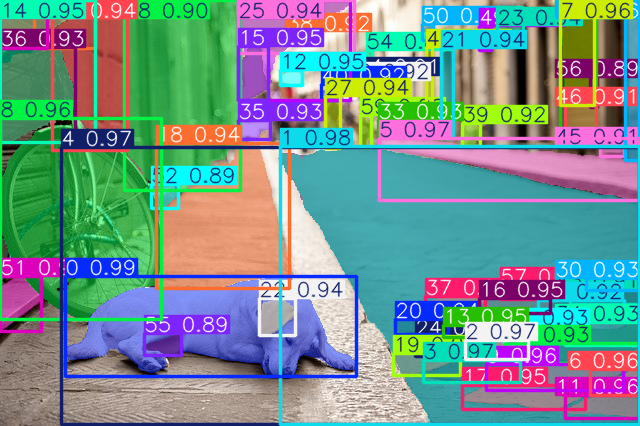

In [8]:

file_path = '/workspace/data/coco128/images/train2017/000000000074.jpg'
results = model(file_path)

results[0].show()


핵심 구상 : 이미지는 16*16 의 패치, 패치마다 768차원의 백터로 표현 트랜스포머 처리 
- text 도 임의 차원을 거쳐서 임베딩으로 만듬   
    -> token이 결국 768 차원 벡터로 되는 것인데 꼭 text일필요는 없다 
- 영상 도 논문 "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"

In [11]:
import keras
from keras import layers
import PIL.Image as Image

model = keras.Sequential([
    layers.Input(shape=(160,160,3)),
    layers.Conv2D(768, kernel_size=16, strides=16), # 패치크기 16*16, embedding demansion 768
])

with Image.open('/workspace/data/mozzi.png') as img:
    img = img.convert('RGB').resize((160,160))
    sample = np.array(img) /255.0 # wjdrbghk 

outputs = model.predict(np.array([sample]))
print(outputs.shape)






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
(1, 10, 10, 768)


## Temporal transformer 

- 시계열 데이터 = 시간에 따라 변하는 데이터, 
- 각 단위를 토큰으로 간주 시예열 데이터를 시퀀스로 처리, 장기 의존성을 효과적으로 캡처 
- huggingface : amazon/chronos-2, pip install "chronos-forecasting>=2.0"



In [ ]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# Load historical target values and past values of covariates
# 실제 사용 시계열 데이터 접목
context_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet")

# (Optional) Load future values of covariates
# 실제 사용 시계열 데이터 접목
test_df = pd.read_parquet("https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet")
future_df = test_df.drop(columns="target")

# Generate predictions with covariates
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    prediction_length=24,  # Number of steps to forecast <- 예측 스탭의 범위 
    quantile_levels=[0.1, 0.5, 0.9],  # Quantiles for probabilistic forecast
    id_column="id",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target="target",  # Column(s) with time series values to predict
)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [13]:
pred_df

,id,timestamp,target_name,predictions,0.1,0.5,0.9
0,DE,2017-12-12 00:00:00,target,22.242922,18.673725,22.242922,25.403454
1,DE,2017-12-12 01:00:00,target,19.525620,14.904278,19.525620,23.316599
2,DE,2017-12-12 02:00:00,target,17.415373,12.209055,17.415373,21.776979
3,DE,2017-12-12 03:00:00,target,16.979263,11.165121,16.979263,21.435223
4,DE,2017-12-12 04:00:00,target,18.058657,12.096773,18.058657,23.166647
5,DE,2017-12-12 05:00:00,target,20.657280,13.990902,20.657280,26.557806
6,DE,2017-12-12 06:00:00,target,28.717491,21.307213,28.717491,34.963543
7,DE,2017-12-12 07:00:00,target,34.779533,26.490700,34.779533,42.546421
8,DE,2017-12-12 08:00:00,target,36.822403,29.011784,36.822403,44.113987
9,DE,2017-12-12 09:00:00,target,35.203396,27.514442,35.203396,42.561340
